In [1]:
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from dotenv import load_dotenv
import datetime
import os
import utils
import random

In [2]:
load_dotenv()
# f"postgres+psycopg2://{[user]}:{[pass]}@{[host}:{[port]}/{[dbname]}"
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}"
)

In [ ]:
start_time='08:00:00'
end_time='09:30:00'
query_min = "SELECT * FROM silver.es_bars WHERE bar_time BETWEEN %(start)s AND %(end)s ORDER BY bar_date, bar_time"
df_min = pd.read_sql(query_min,engine, params={"start": start_time, "end": end_time})

In [4]:
df_swings= utils.get_swings(df_min)
df_swings['profit'] = np.where(
    df_swings['trend']=='UP', 
    abs(df_swings['open']-df_swings['high']), 
    abs(df_swings['open']-df_swings['low'])
)
df_swings = utils.add_winsorized_col(df_swings,'profit')

In [5]:
chart_day= None
def chart_visualize(date=None):
    global chart_day
    chart_day = df_min['bar_date'].iloc[random.randint(0,len(df_min))] if date is None else date
    print(chart_day)
    utils.display_market_chart(df_min,chart_day)
    utils.display_market_chart(df_swings,chart_day,date_col='date',time_col='time_start')

findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight semibold, now using 700.


2025-04-21


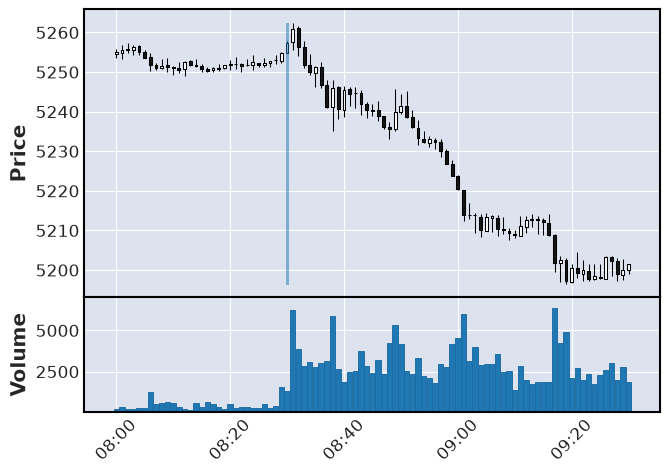

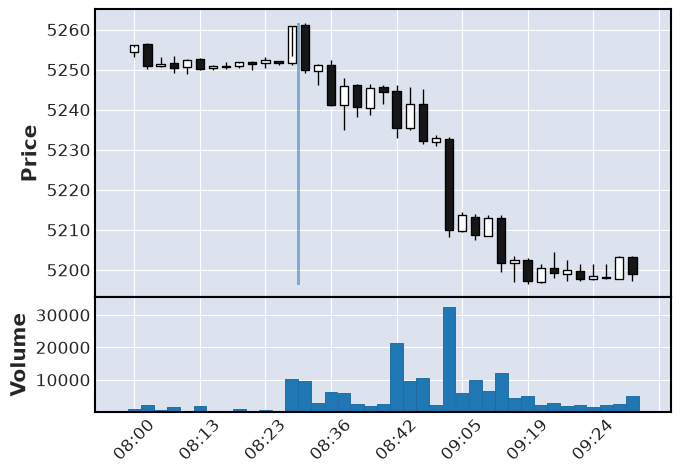

In [6]:
#2025-01-28
date = datetime.date(2025,1,28)
chart_visualize()

In [7]:
df_swings[df_swings['date']==chart_day]

,date,time_start,time_end,high,open,close,low,volume,following_price_movement,fighting_price_movememnt,trend,bucket_30min,bucket_15min,bucket_5min,profit,profit_winsorized
3096,2025-04-21,08:00:00,08:03:00,5255.75,5254.50,5256.25,5253.25,1028.0,6.00,4.75,UP,08:00:00,08:00:00,08:00:00,1.25,1.25
3097,2025-04-21,08:04:00,08:07:00,5256.75,5256.50,5251.00,5250.25,2353.0,8.50,2.25,DOWN,08:00:00,08:00:00,08:00:00,6.25,6.25
3098,2025-04-21,08:08:00,08:08:00,5253.25,5251.00,5251.50,5250.75,584.0,2.25,0.25,UP,08:00:00,08:00:00,08:05:00,2.25,2.25
3099,2025-04-21,08:09:00,08:11:00,5253.50,5251.75,5250.50,5249.25,1599.0,5.00,3.50,DOWN,08:00:00,08:00:00,08:05:00,2.50,2.50
3100,2025-04-21,08:12:00,08:12:00,5252.75,5250.75,5252.50,5249.00,245.0,2.00,1.75,UP,08:00:00,08:00:00,08:10:00,2.00,2.00
3101,2025-04-21,08:13:00,08:16:00,5253.00,5252.75,5250.25,5250.00,1818.0,4.00,2.75,DOWN,08:00:00,08:00:00,08:10:00,2.75,2.75
3102,2025-04-21,08:17:00,08:17:00,5251.25,5250.50,5251.00,5250.00,507.0,0.75,0.50,UP,08:00:00,08:15:00,08:15:00,0.75,0.75
3103,2025-04-21,08:18:00,08:18:00,5252.00,5251.00,5250.75,5250.25,350.0,0.75,1.00,DOWN,08:00:00,08:15:00,08:15:00,0.75,0.75
3104,2025-04-21,08:19:00,08:21:00,5251.75,5251.00,5252.00,5250.50,1068.0,3.75,2.75,UP,08:00:00,08:15:00,08:15:00,0.75,0.75
3105,2025-04-21,08:22:00,08:22:00,5252.25,5252.00,5251.50,5250.00,340.0,2.00,0.25,DOWN,08:00:00,08:15:00,08:20:00,2.00,2.00
